### This scripts is used to rerun the optimed models, to get all metrics and cross validation scores:


INPUT files: 
* nutrient data with catchment features
* table contraining optimized parameter sets for each  model

SETTINGS:
* target_var
* model_type
  

load required packages:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms
from sklearn import metrics
from numpy import mean
from numpy import std
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
import time
import os
import ast

### Set target_var and model type: 

In [2]:
# select target_var: n_imbal, c_imbal, p_imbal, median_DIN, median_SRP or median_DOC_TOC_bioav
target_var = 'p_imbal'

#select model type: 'gbr'
model_type = 'gbr'


Import dataset:

In [4]:
nutrient_export_data = pd.read_csv('../../../output_data/input_ML_learning/median_cnp_export_abs_conc_and_rfr_and_basin_feat.csv').drop(columns='Unnamed: 0')

Import optimized parameter sets:

In [5]:
optimized_parameter_sets = pd.read_csv('../../../output_data/ML_analysis/hyperparameter_settings/optimized_model_parms_for_importance_calculation.csv', sep = ';', dtype={'parameters': str})

# Convert the 'parameters' column to dictionaries
optimized_parameter_sets['parameters'] = optimized_parameter_sets['parameters'].apply(ast.literal_eval)

In [6]:
optimized_parameter_sets

,model,target,parameters,transformation
0,gbr,c_imbal,"{'learning_rate': 0.0018911001294483038, 'max_...",box-cox
1,gbr,n_imbal,"{'learning_rate': 0.001524207186070734, 'max_d...",box-cox
2,gbr,p_imbal,"{'learning_rate': 0.0018696900876637153, 'max_...",box-cox
3,gbr,median_DOC_TOC_bioav,"{'learning_rate': 0.0019202958248987234, 'max_...",box-cox
4,gbr,median_DIN,"{'learning_rate': 0.00420545212113823, 'max_de...",box-cox
5,gbr,median_SRP,"{'learning_rate': 0.0014628853574732998, 'max_...",box-cox
6,lightgbm,c_imbal,"{'colsample_bytree': 0.4, 'learning_rate': 0.0...",box-cox
7,lightgbm,n_imbal,"{'colsample_bytree': 0.4, 'learning_rate': 0.0...",box-cox
8,lightgbm,p_imbal,"{'colsample_bytree': 0.4, 'learning_rate': 0.0...",box-cox
9,lightgbm,median_DIN,"{'colsample_bytree': 0.4, 'learning_rate': 0.0...",box-cox


## Prepare the data for the machine learning models:

1. Split data into features and targets
2. Convert data frame to arrays 
3. Split data into training and test set

1. Function to prepare input data: split data into target and features and convert to arrays: 

In [7]:

def create_input_ML(data, target_var):

    # create array with exported nutrient values, which are our target values, we want to predict 
    target = np.array(nutrient_export_data[target_var])


    # remove the labels from the features df:

    features = nutrient_export_data.drop(['HYBAS_ID', 'n_imbal', 'p_imbal', 'c_imbal', 'median_DOC_TOC_bioav', 'median_DIN', 'median_SRP'], axis = 1)
    #features = nutrient_export_data.filter(items=selected_features)

    #select columns by index: 
    features= features.iloc[:,0:43]
    features.columns

    # save feature list for later use:
    feature_list = list(features.columns)

    # convert to numpy array:
    #features = np.array(features)

    return target, features, feature_list

### Apply create_input_ML function:

In [8]:
# data:
data = nutrient_export_data

In [9]:
target, features, feature_list = create_input_ML(data = data, target_var = target_var)

### Fit Boosting regression tree using best  parameters:

In [10]:
# extract best parameters: squeeze() funtion is required, to convert Series object to one value (result of loc operation is always a pandas series, even if output is only one value):
best_parms =  optimized_parameter_sets.loc[(optimized_parameter_sets['target'] == target_var) & (optimized_parameter_sets['model'] == model_type), 'parameters'].squeeze()

In [11]:
best_parms

{'learning_rate': 0.0018696900876637153,
 'max_depth': 11,
 'max_features': 5,
 'n_estimators': 3650,
 'subsample': 0.7}

Set random state values: use values from model optimization: 

In [12]:
# test size: usually 0.2 
test_size = 0.2
#set random_state:
random_state = 41 


In [13]:

# using Skicit-learn to split data into training and testing sets:
from sklearn.model_selection import train_test_split

train_features, test_features, train_targets, test_targets = train_test_split(features, target, test_size = test_size, random_state = random_state) 


Check data structure: targets and features should have same length in training and test set:

In [14]:
print('Training Features Shape:', train_features.shape)
print('Training targets Shape:', train_targets.shape)
print('Testing Features Shape:', test_features.shape)
print('Testing targets Shape:', test_targets.shape)

Training Features Shape: (2796, 33)
Training targets Shape: (2796,)
Testing Features Shape: (700, 33)
Testing targets Shape: (700,)


### Box-Cox transformation of training and testing targets:

In [15]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='box-cox')

# Reshape train_targets to 2D if it's 1D
if len(train_targets.shape) == 1:
    train_targets2 = np.reshape(train_targets, (-1, 1))

# Fit the transformer to the training data
# This learns the best lambda value for each feature
pt.fit(train_targets2)

# Transform the training data using the learned lambda values
train_targets_transformed_bc = pt.transform(train_targets2)
# convert back to 1D format
train_targets_transformed_bc = train_targets_transformed_bc.ravel()

# Transform the test data using the same lambda values
# Reshape test_targets to 2D if it's 1D
if len(test_targets.shape) == 1:
    test_targets2 = np.reshape(test_targets, (-1, 1))

test_targets_transformed_bc = pt.transform(test_targets2)
test_targets_transformed_bc = test_targets_transformed_bc.ravel()

# Set configurations of cross-validation:

In [16]:
# define the evaluation procedure
from sklearn.model_selection import RepeatedKFold
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)




### Now fit the model:

In [17]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error



model = GradientBoostingRegressor(**best_parms,  random_state = 5)


# Fit the model applying 10fold cross validation:
n_scores = cross_val_score(model, train_features, train_targets_transformed_bc, scoring = 'r2', cv = cv, n_jobs = 40, verbose = 10)



[Parallel(n_jobs=40)]: Using backend LokyBackend with 40 concurrent workers.
[Parallel(n_jobs=40)]: Done   3 out of  30 | elapsed:   59.4s remaining:  8.9min
[Parallel(n_jobs=40)]: Done   7 out of  30 | elapsed:  1.2min remaining:  4.0min
[Parallel(n_jobs=40)]: Done  11 out of  30 | elapsed:  1.3min remaining:  2.2min
[Parallel(n_jobs=40)]: Done  15 out of  30 | elapsed:  1.4min remaining:  1.4min
[Parallel(n_jobs=40)]: Done  19 out of  30 | elapsed:  1.4min remaining:   49.2s
[Parallel(n_jobs=40)]: Done  23 out of  30 | elapsed:  1.4min remaining:   26.2s
[Parallel(n_jobs=40)]: Done  27 out of  30 | elapsed:  1.5min remaining:    9.6s
[Parallel(n_jobs=40)]: Done  30 out of  30 | elapsed:  1.5min finished


In [18]:
R2_cross_val_mean = round(np.mean(n_scores),2)
R2_cross_val_std = round(np.std(n_scores),2)

In [20]:
model.fit(train_features, train_targets_transformed_bc)
    
    
# make predictions on train- and test-features:
pred_train = model.predict(train_features)
pred_test = model.predict(test_features)

r2_train = round(r2_score(train_targets_transformed_bc, pred_train),2)
r2_test = round(r2_score(test_targets_transformed_bc, pred_test),2)


# mean absolute percentage error  test data
MAPE = round(mean_absolute_percentage_error(test_targets_transformed_bc, pred_test),2)
    
# mean squared error: 
mse = round(mean_squared_error(test_targets_transformed_bc, pred_test),2)
   
# mean absolute error: 
mae = round(mean_absolute_error(test_targets_transformed_bc, pred_test), 2)

print(f"R2 Train: {r2_train}")
print(f"R2 Test: {r2_test}")

# put all results together 
results = {'estimator' : [str(model_type)],
            'target': [str(target_var)],
            'R2_train':[r2_train],
            'R2_cross_val_mean':[R2_cross_val_mean],
            'R2_cross_val_std':[R2_cross_val_std],
            'R2_test':[r2_test],
            'MAPE': [MAPE],
            'mse':[mse],
            'mae':[mae]
            }
# convert results to data frame
table_results = pd.DataFrame(results)



R2 Train: 0.99
R2 Test: 0.37


In [21]:
path = f'../../../output_data/ML_analysis/rerun_optimized_models_performance_scores.csv'
path_excel = f'../../../output_data/ML_analysis/rerun_optimized_models_performance_scores.xlsx'


# check if csv-file already exists: 
isdir = os.path.isfile(path)
print(isdir)
# if not save df to new csv: 
if isdir == False:
    table_results.to_csv(path, index = False)
    table_results.to_excel(path_excel, index = False)
# if already exists, concat new results: 
else:
    already_exist = pd.read_csv(path)
    data_table =pd.concat([already_exist, table_results], ignore_index = True)
    data_table.to_csv(path, index = False)
    data_table.to_excel(path_excel, index = False)
        
        

False


Now plot the results in barplots:

In [22]:
path = f'../../../output_data/ML_analysis/rerun_optimized_models_performance_scores.csv'
scores = pd.read_csv(path)

In [23]:
scores

,estimator,target,R2_train,R2_cross_val_mean,R2_cross_val_std,R2_test,MAPE,mse,mae
0,gbr,p_imbal,0.99,0.41,0.05,0.37,1.96,0.62,0.6


In [24]:
scores['target_variable'] = ['median rOC', 'median DIN', 'median SRP', 'rOC$_{RFR}$', 'DIN$_{RFR}$','SRP$_{RFR}$']

ValueError: Length of values (6) does not match length of index (1)

In [ ]:
scores

,estimator,target,R2_train,R2_cross_val_mean,R2_cross_val_std,R2_test,MAPE,mse,mae,target_variable
0,gbr,median_DOC_TOC_bioav,0.99,0.70,0.05,0.77,1.63,0.21,0.33,median rOC
1,gbr,median_DIN,1.00,0.72,0.04,0.67,1.12,0.35,0.39,median DIN
2,gbr,median_SRP,0.98,0.53,0.04,0.53,5.72,0.45,0.48,median SRP
3,gbr,c_imbal,0.96,0.62,0.04,0.66,1.21,0.34,0.43,rOC$_{RFR}$
4,gbr,n_imbal,1.00,0.54,0.06,0.51,2.91,0.51,0.52,DIN$_{RFR}$
5,gbr,p_imbal,0.99,0.41,0.05,0.38,1.97,0.62,0.60,SRP$_{RFR}$


C:\Users\bartusch\AppData\Local\Temp\45\ipykernel_52400\948873313.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(scores['target_variable'], rotation=45, ha='right', fontsize=14)
C:\Users\bartusch\AppData\Local\Temp\45\ipykernel_52400\948873313.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(scores['target_variable'], rotation=45, ha='right', fontsize=14)


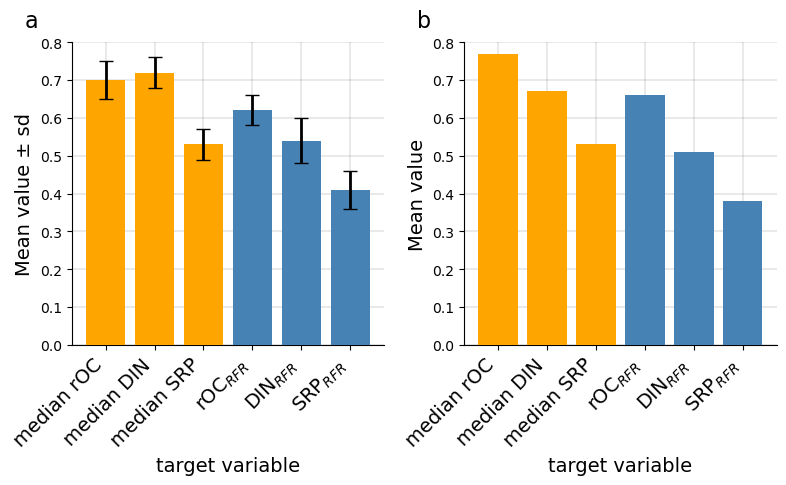

In [ ]:
colors = ['orange', 'orange', 'orange', 'steelblue', 'steelblue', 'steelblue']

fig, axes = plt.subplots(1,2, figsize = (8, 5))

axes = axes.flatten()
axes[0].bar(scores['target_variable'], scores['R2_cross_val_mean'], yerr = scores['R2_cross_val_std'], capsize = 5, color = colors, error_kw = {'elinewidth':2, 'ecolor':'black'}, zorder = 3)
axes[0].set_xlabel('target variable', fontsize = 14)
axes[0].set_ylabel('Mean value ± sd', fontsize = 14)
axes[0].set_xticklabels(scores['target_variable'], rotation=45, ha='right', fontsize=14)
axes[0].set_ylim(0, 0.8)
axes[0].text(-0.15, 1.05, 'a', transform=axes[0].transAxes, 
             size=16)#, weight='bold')
axes[0].grid(color='gray', linestyle='-', linewidth=0.25, zorder = -1)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)



axes[1].bar(scores['target_variable'], scores['R2_test'], color = colors, zorder = 3)
axes[1].set_xlabel('target variable', fontsize = 14)
axes[1].set_ylabel('Mean value', fontsize = 14)
axes[1].set_xticklabels(scores['target_variable'], rotation=45, ha='right', fontsize=14)
axes[1].set_ylim(0, 0.8)

axes[1].text(-0.15, 1.05, 'b', transform=axes[1].transAxes, 
             size=16)#, weight='bold')
axes[1].grid(color='gray', linestyle='-', linewidth=0.25, zorder = -1)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('../../figures/other_plots_master_thesis/cross_val_scores_ml_models.png')
plt.show()